In [ ]:
import numpy as np
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

from cashflows import basket_geom_asian_cashflows

## Test dataset

Simulation of risk factors and discounted cash flows

In [8]:
num_risk_factors = 3
initial_spot_values = [100.0, 95.0, 105.0]
risk_free_rate = 0.03
drift_array = [risk_free_rate, risk_free_rate, risk_free_rate]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0.0, 5.0, 61)
num_sims = 30000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)


paths_risk_factors = simulator.simulate_paths(num_sims=num_sims)

results = basket_geom_asian_cashflows(time_steps, risk_free_rate, 3, paths_risk_factors, 
                                      True, 1.0, "cpu", torch.float64, False)


In [9]:
np.save('../../DATA/X_CVA_train.npy', paths_risk_factors.numpy()[0:20000])
np.save('../../DATA/X_CVA_valid.npy', paths_risk_factors.numpy()[20000:])
np.save('../../DATA/y_CVA_train.npy', results['discounted_cashflows'].numpy()[0:20000])
np.save('../../DATA/y_CVA_valid.npy', results['discounted_cashflows'].numpy()[20000:])

In [10]:
from dataset import DeepLearningCVADataset

x_train_str = '../../DATA/X_CVA_train.npy'
x_valid_str = '../../DATA/X_CVA_valid.npy'
y_train_str = '../../DATA/y_CVA_train.npy'
y_valid_str = '../../DATA/y_CVA_valid.npy'

CVA_train_dataset = DeepLearningCVADataset(x_train_str, y_train_str, torch.float64)

CVA_valid_dataset = DeepLearningCVADataset(x_valid_str, y_valid_str, torch.float64,1e-8,
                CVA_train_dataset.X_mu, CVA_train_dataset.X_sigma, CVA_train_dataset.y_mu,
                CVA_train_dataset.y_sigma)

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(CVA_train_dataset, batch_size= 264)
valid_loader = DataLoader(CVA_valid_dataset, batch_size= 264)


train_iter = iter(train_loader)
valid_iter = iter(valid_loader)

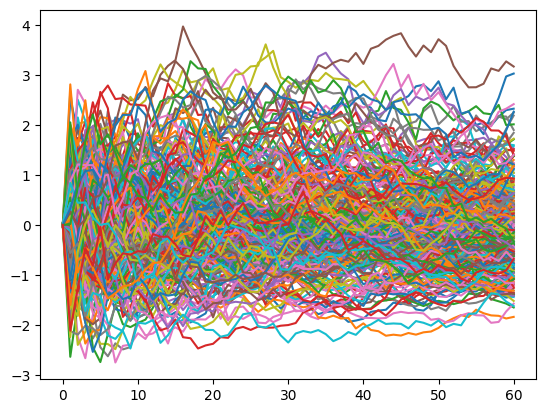

In [ ]:
x, y = next(train_iter)


plt.plot(x.numpy()[:,:,0].T);



In [ ]:
plt.plot

tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 5.7504e-01,  2.8017e-01, -3.1715e-01],
         [ 8.5118e-01,  8.8298e-01, -7.9273e-01],
         ...,
         [-2.5194e-01, -1.0329e+00,  2.5890e+00],
         [-3.0147e-01, -1.0180e+00,  2.0919e+00],
         [-1.0768e-01, -1.0031e+00,  2.8014e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [-1.3574e+00, -3.3499e-01, -1.4572e+00],
         [-1.1824e+00, -8.0495e-01, -3.8700e-01],
         ...,
         [-7.7301e-01, -4.1038e-01, -5.9811e-01],
         [-6.9562e-01, -4.3863e-01, -5.4670e-01],
         [-7.8805e-01, -5.0602e-01, -5.4403e-01]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 2.2602e-01, -2.9857e-03,  2.8467e-01],
         [-1.0760e-01, -3.2161e-01,  3.8771e-01],
         ...,
         [ 9.6016e-01, -5.2678e-02,  8.4841e-01],
         [ 8.9691e-01, -1.7040e-01,  1.0568e+00],
         [ 5.7453e-01, -2.4615e-01,  7.7525e-01]],

        ...,

        [[ 0.0000e+00,  0.0000e+00,  0